In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words = open('../datasets/names.txt', 'r').read().splitlines()
print(words[:10])
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
32033
2
15


## Bigram language model
Bigram LM is always works with only two characters

In [6]:
for w in words[:2]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>


In [7]:
# b stores infomation about which combinations occure most often
b = {}
for w in words:
    chs = ['<.>'] + list(w) + ['<.>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(bigram)

In [8]:
# fin most common combinations
sorted(b.items(), key=lambda kv: -kv[1])[:10]

[(('n', '<.>'), 6763),
 (('a', '<.>'), 6640),
 (('a', 'n'), 5438),
 (('<.>', 'a'), 4410),
 (('e', '<.>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<.>', 'k'), 2963)]

In [9]:
chars = sorted(list(set(''.join(words))))
print(chars)
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(stoi)
print(itos)


['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


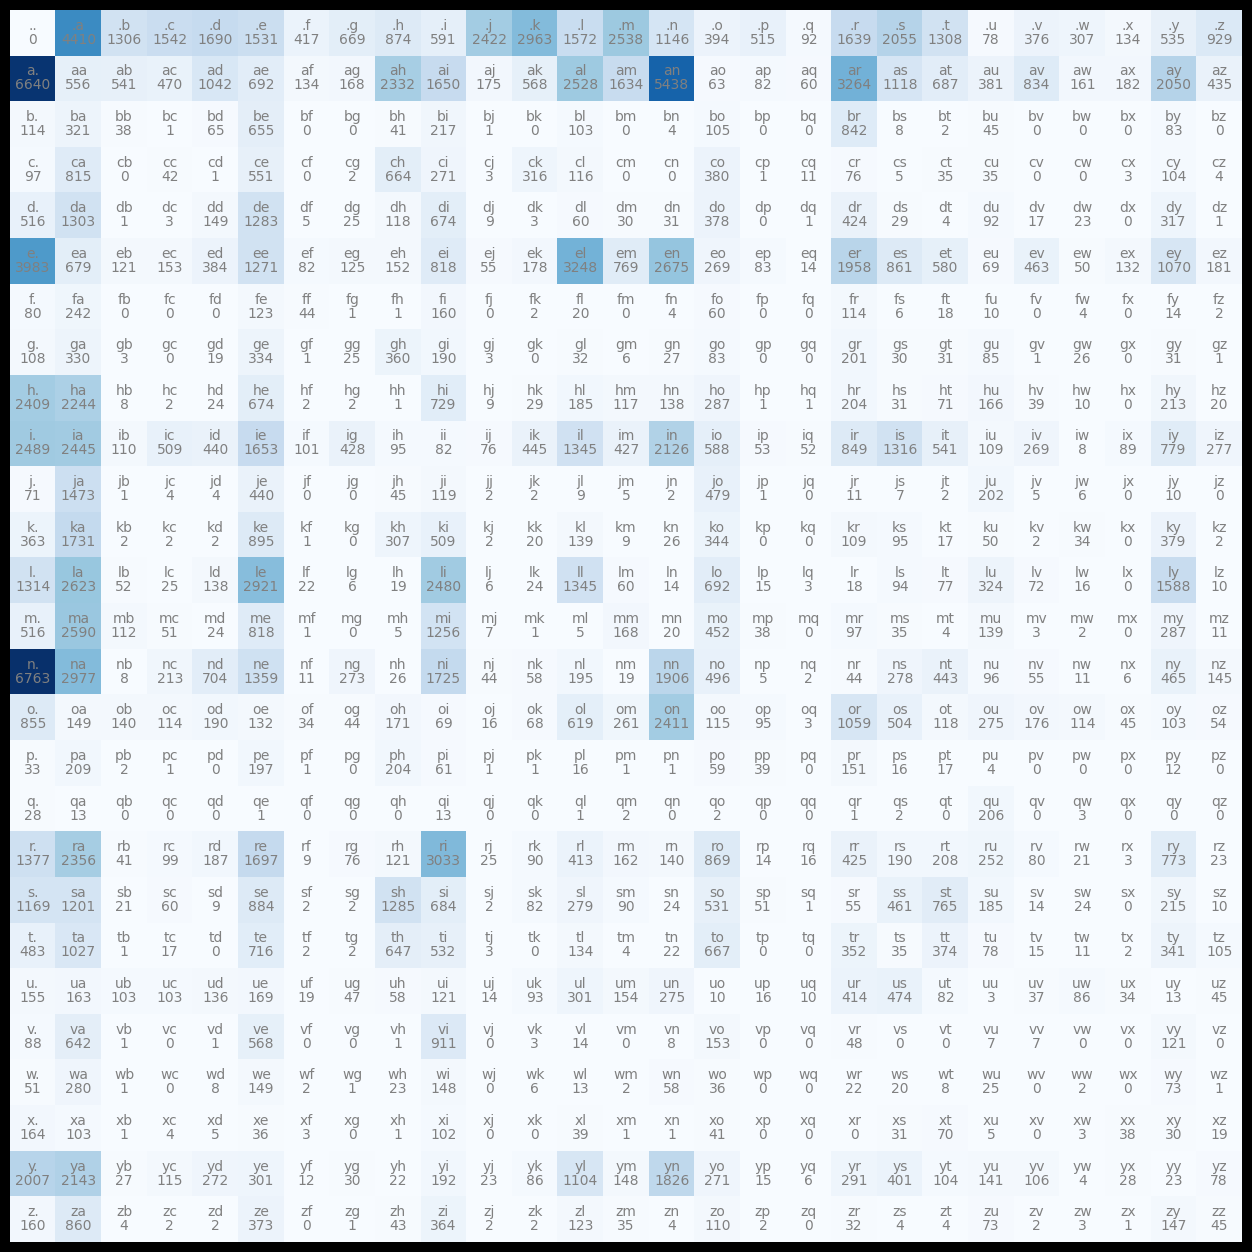

In [10]:
# we want to store information about which combination occurs how often in a 2d array:
# row will represent first character in bigram, column will represent 2nd character
# value will be count

N = torch.zeros((27, 27), dtype=torch.int32) # 26 chars + special token

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [11]:
print(N[0, :])
print(N[0, :].shape)

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)
torch.Size([27])


In [12]:
# sampling from the model (creating probabilities)
p = N[0].float()
print(p.sum())
p = p / p.sum()
print(p)
print(p.sum())
print("==")
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
print(p)
p = p / p.sum()
print(p)

sample = torch.multinomial(p, num_samples=20, replacement=True, generator=g)
print(sample)


tensor(32033.)
tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])
tensor(1.)
==
tensor([0.7081, 0.3542, 0.1054])
tensor([0.6064, 0.3033, 0.0903])
tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])


In [13]:
p = N[0].float()
p = p / p.sum()
print(p)
g = torch.Generator().manual_seed(2147483647)
sample = torch.multinomial(p, num_samples=20, replacement=True, generator=g)
print(sample)
print([itos[idx.item()] for idx in sample])



tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])
tensor([13, 19, 14,  1,  1, 20, 20,  1, 13, 13, 13, 11, 23, 13, 19, 18, 26, 11,
         7, 19])
['m', 's', 'n', 'a', 'a', 't', 't', 'a', 'm', 'm', 'm', 'k', 'w', 'm', 's', 'r', 'z', 'k', 'g', 's']


In [14]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):
    ix = 0
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [15]:
# we are increasing every entry by 1 so we wont have zero probabilities
P = (1 + N).float()
print(P.sum(1, keepdim=False))
print(P.sum(1, keepdim=True))
P /= P.sum(1, keepdim=True)
print(P[0].sum())
print(P[3].sum())

tensor([32060., 33912.,  2672.,  3559.,  5523., 20450.,   932.,  1954.,  7643.,
        17728.,  2927.,  5067., 13985.,  6669., 18354.,  7961.,  1053.,   299.,
        12727.,  8133.,  5597.,  3162.,  2600.,   956.,   724.,  9803.,  2425.])
tensor([[32060.],
        [33912.],
        [ 2672.],
        [ 3559.],
        [ 5523.],
        [20450.],
        [  932.],
        [ 1954.],
        [ 7643.],
        [17728.],
        [ 2927.],
        [ 5067.],
        [13985.],
        [ 6669.],
        [18354.],
        [ 7961.],
        [ 1053.],
        [  299.],
        [12727.],
        [ 8133.],
        [ 5597.],
        [ 3162.],
        [ 2600.],
        [  956.],
        [  724.],
        [ 9803.],
        [ 2425.]])
tensor(1.)
tensor(1.)


In [16]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    ix = 0
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## Maximum likelihood probability estimation
our goal is to maximize likelihood of the data w.r.t. model parameters (statistical modeling) equivalent to maximizing the log likelihood (because log is monotonic)
which is equivalent of minimizing the negative log likelihood
and equivalent of minimizing the average negative log likelihood

In [17]:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']

    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f"{ch1}{ch2}: {prob:.4f} {logprob:.4f}")
nll = -log_likelihood
print(nll)
print(nll/n)


tensor(559951.5625)
tensor(2.4544)


## PART 2


In [18]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# one_hot converts integer into tensor with classification:
# len of tensor is num of classes and everything set to 0,
# except value at index of our original value set to 1
# ex: 3 becomes [0,0,0,1,0,0...0]
xenc = F.one_hot(xs, num_classes=27).float()
xenc.shape


torch.Size([5, 27])

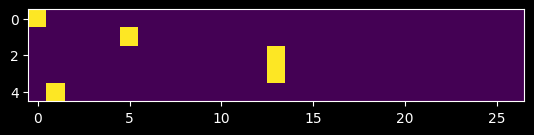

In [19]:
plt.imshow(xenc)

In [20]:
W = torch.randn(27,27)
print(xenc.shape)
print(W.shape)
# @ is multiplication
mr = (xenc @ W)
mr.shape

torch.Size([5, 27])
torch.Size([27, 27])


torch.Size([5, 27])

In [21]:
mr[3, 13]

tensor(1.3280)

In [22]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [23]:
W[:, 13]

tensor([-0.0931,  0.4363, -0.3798,  0.2457,  0.6825,  1.5151,  0.1396,  0.7094,
         0.5096,  0.5586, -0.4826, -0.1235, -0.9479,  1.3280,  0.4704, -0.8887,
         1.3227, -0.1079, -0.7815, -0.7393,  1.2952, -0.4196,  0.4842,  0.1775,
        -1.3977,  0.6092, -0.3474])

In [24]:
(xenc[3] @ W[:, 13]).sum()

tensor(1.3280)

neural net will only have a one single layer with 27 neurons, every neuron output will represent probability of a character from corresponding index to appear after input
to achieve this we will interpret results as log counts, then exp them then normalize over sum
exponentiation and normalization is a very common operation in deep learning and its called softmax

In [25]:
logits = xenc @ W # log counts
counts = logits.exp() # counts
probs = counts / counts.sum(1, keepdim=True)
print(probs)
print(probs[0].sum())
print(probs.shape)

tensor([[0.0180, 0.1280, 0.0197, 0.0103, 0.0809, 0.0047, 0.0474, 0.0319, 0.0129,
         0.0047, 0.0222, 0.0465, 0.0169, 0.0242, 0.0534, 0.0035, 0.0579, 0.0264,
         0.0079, 0.0589, 0.0539, 0.1004, 0.0663, 0.0084, 0.0595, 0.0082, 0.0267],
        [0.0111, 0.0223, 0.0305, 0.0110, 0.0538, 0.0149, 0.0698, 0.0333, 0.0081,
         0.0087, 0.0584, 0.0230, 0.0043, 0.0908, 0.0195, 0.0201, 0.0169, 0.0085,
         0.3098, 0.0026, 0.0156, 0.0056, 0.0221, 0.0218, 0.0448, 0.0063, 0.0665],
        [0.0776, 0.0147, 0.1033, 0.0146, 0.0113, 0.0054, 0.0112, 0.0121, 0.0382,
         0.0336, 0.1184, 0.0653, 0.0892, 0.0673, 0.0103, 0.0171, 0.0309, 0.0053,
         0.0060, 0.0063, 0.0208, 0.0090, 0.0308, 0.0304, 0.0733, 0.0665, 0.0311],
        [0.0776, 0.0147, 0.1033, 0.0146, 0.0113, 0.0054, 0.0112, 0.0121, 0.0382,
         0.0336, 0.1184, 0.0653, 0.0892, 0.0673, 0.0103, 0.0171, 0.0309, 0.0053,
         0.0060, 0.0063, 0.0208, 0.0090, 0.0308, 0.0304, 0.0733, 0.0665, 0.0311],
        [0.0909, 0.0820,

In [26]:
#example of loss calculation for 5 bigrams:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()
    print("---------")
    print(f"bigram example {i+1}: {itos[x]}{itos[y]} indexes {x},{y}")
    print(f"input to neural net {x}")
    print(f"output probabilities from NN: ", probs[i])
    print(f"label (or expected value from ys):", y)
    p = probs[i, y]
    print("probability assigned by NN to the correct value:", p.item())
    logp = torch.log(p)
    print("log likelihood:", logp.item())
    nll = -logp
    print("negative log likelihood", nll.item())
    nlls[i] = nll
print("-----")
print("average log likelihood, i.e. loss = ", nlls.mean().item())

---------
bigram example 1: .e indexes 0,5
input to neural net 0
output probabilities from NN:  tensor([0.0180, 0.1280, 0.0197, 0.0103, 0.0809, 0.0047, 0.0474, 0.0319, 0.0129,
        0.0047, 0.0222, 0.0465, 0.0169, 0.0242, 0.0534, 0.0035, 0.0579, 0.0264,
        0.0079, 0.0589, 0.0539, 0.1004, 0.0663, 0.0084, 0.0595, 0.0082, 0.0267])
label (or expected value from ys): 5
probability assigned by NN to the correct value: 0.004729346372187138
log likelihood: -5.353968143463135
negative log likelihood 5.353968143463135
---------
bigram example 2: em indexes 5,13
input to neural net 5
output probabilities from NN:  tensor([0.0111, 0.0223, 0.0305, 0.0110, 0.0538, 0.0149, 0.0698, 0.0333, 0.0081,
        0.0087, 0.0584, 0.0230, 0.0043, 0.0908, 0.0195, 0.0201, 0.0169, 0.0085,
        0.3098, 0.0026, 0.0156, 0.0056, 0.0221, 0.0218, 0.0448, 0.0063, 0.0665])
label (or expected value from ys): 13
probability assigned by NN to the correct value: 0.09080773591995239
log likelihood: -2.399010896682739

## now start building actual NN

In [27]:
xs, ys = [], []

for w in words[:]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print("Number of examples", num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)


Number of examples 228146


In [28]:

for k in range(100):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)

    #loss
    # a way to index probs tensor - arange produces sequence 0,1,2,3,4 and ys is our labels
    # this allows us to query probability for each row and its corresponding label
    
    # print(probs[torch.arange(num), ys])
    
    # now use it to calc loss
    loss = -probs[torch.arange(num), ys].log().mean()
    # its possible to smooth out our weights here too, just like we did it with table before
    # to achieve this, we can make our weights positive and add them to loss, so when we
    # do backprop it will be affected by values of weight as well and SGD will be gravitated
    # towards lower values of W:
    #loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W ** 2).mean()
    # but this approach makes loss calc less efficient, so its usually optional
    
    print("loss", loss.item())

    #backward pass
    W.grad = None # set gradients to zero
    loss.backward()
    # print(W.grad.shape)

    # update
    W.data += -50 * W.grad


# what loss value do we expect to reach? it should be similar to # what we calculated 
# with counts of 2d table and and maximum likelihood prob estimation, 
# which was 2.4541 without smoothing

loss 3.758953094482422
loss 3.371100664138794
loss 3.154043197631836
loss 3.020373821258545
loss 2.927711248397827
loss 2.8604023456573486
loss 2.8097290992736816
loss 2.7701022624969482
loss 2.7380731105804443
loss 2.711496353149414
loss 2.6890032291412354
loss 2.6696884632110596
loss 2.6529300212860107
loss 2.638277292251587
loss 2.6253879070281982
loss 2.613990545272827
loss 2.60386323928833
loss 2.5948216915130615
loss 2.5867116451263428
loss 2.5794036388397217
loss 2.572789192199707
loss 2.5667762756347656
loss 2.5612881183624268
loss 2.5562589168548584
loss 2.551633596420288
loss 2.547366142272949
loss 2.543415069580078
loss 2.5397486686706543
loss 2.536336660385132
loss 2.533154249191284
loss 2.5301806926727295
loss 2.5273966789245605
loss 2.5247862339019775
loss 2.522334575653076
loss 2.520029067993164
loss 2.517857789993286
loss 2.515810489654541
loss 2.513878345489502
loss 2.512052059173584
loss 2.510324001312256
loss 2.5086867809295654
loss 2.5071346759796143
loss 2.50566148

In [29]:
# now, lets sample (generate) from our trained neural net:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyauelalerigotai.
moliellavo.
ke.
teda.
